<a href="https://colab.research.google.com/github/JotiNARINDER/ecg-arrhythmia-classification/blob/main/ECG_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install wfdb

In [4]:
!pip install wfdb -q

import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def bandpass_filter(signal, lowcut=0.5, highcut=50, fs=360, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

print("Tout est prêt")

Tout est prêt


In [5]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print ("tout est installé")

tout est installé


In [6]:
!pip install wfdb -q
print(" wfdb installé")

 wfdb installé


In [7]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

print(" Toutes les librairies importées")

 Toutes les librairies importées


In [8]:
# Téléchargement dataset depuis PhysioNet
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

print(f"Signal chargé")
print(f"Fréquence d'échantillonnage : {record.fs} Hz")
print(f"Durée : {record.sig_len / record.fs / 60:.1f} minutes")
print(f"Nombre de battements annotés : {len(annotation.sample)}")

Signal chargé
Fréquence d'échantillonnage : 360 Hz
Durée : 30.1 minutes
Nombre de battements annotés : 2274


In [9]:
import os

# Télécharger en local dans Colab
wfdb.dl_database('mitdb', dl_dir='./mitdb_data', records=['100', '101', '103'])

# Voir les fichiers téléchargés
for f in os.listdir('./mitdb_data'):
    print(f)

Generating record list for: 100
Generating record list for: 101
Generating record list for: 103
Generating list of all files for: 100
Generating list of all files for: 101
Generating list of all files for: 103
Created local base download directory: ./mitdb_data
Finished downloading files
103.atr
100.hea
101.hea
103.hea
100.dat
101.atr
101.dat
103.dat
100.atr


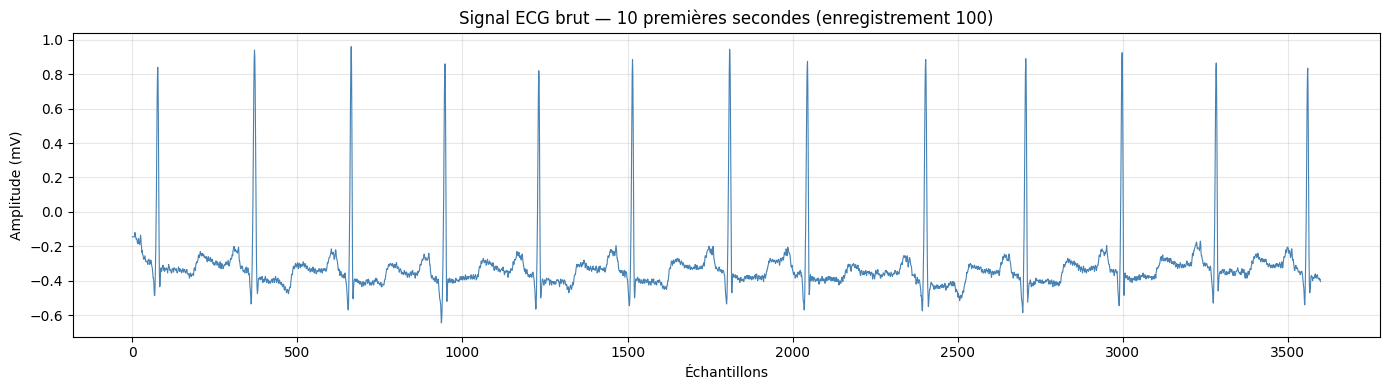

In [10]:
record = wfdb.rdrecord('./mitdb_data/100')
annotation = wfdb.rdann('./mitdb_data/100', 'atr')

fs = record.fs
signal = record.p_signal[:, 0]

plt.figure(figsize=(14, 4))
plt.plot(signal[:fs*10], color='steelblue', linewidth=0.8)
plt.title("Signal ECG brut — 10 premières secondes (enregistrement 100)")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude (mV)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
# j'affiche les 20 premiers battements et leur label
print("Positions des battements et leur type :")
print(f"{'Index':<8} {'Position':<12} {'Label':<10} {'Signification'}")
print("-" * 50)

signification = {
    'N': 'Normal',
    'L': 'Bloc branche gauche',
    'R': 'Bloc branche droite',
    'V': 'Battement ventriculaire',
    'A': 'Battement auriculaire',
    'F': 'Fusion',
    '/': 'Pacemaker'
}

for i in range(20):
    sym = annotation.symbol[i]
    pos = annotation.sample[i]
    sig = signification.get(sym, 'Autre')
    print(f"{i:<8} {pos:<12} {sym:<10} {sig}")

Positions des battements et leur type :
Index    Position     Label      Signification
--------------------------------------------------
0        18           +          Autre
1        77           N          Normal
2        370          N          Normal
3        662          N          Normal
4        946          N          Normal
5        1231         N          Normal
6        1515         N          Normal
7        1809         N          Normal
8        2044         A          Battement auriculaire
9        2402         N          Normal
10       2706         N          Normal
11       2998         N          Normal
12       3282         N          Normal
13       3560         N          Normal
14       3862         N          Normal
15       4170         N          Normal
16       4466         N          Normal
17       4764         N          Normal
18       5060         N          Normal
19       5346         N          Normal


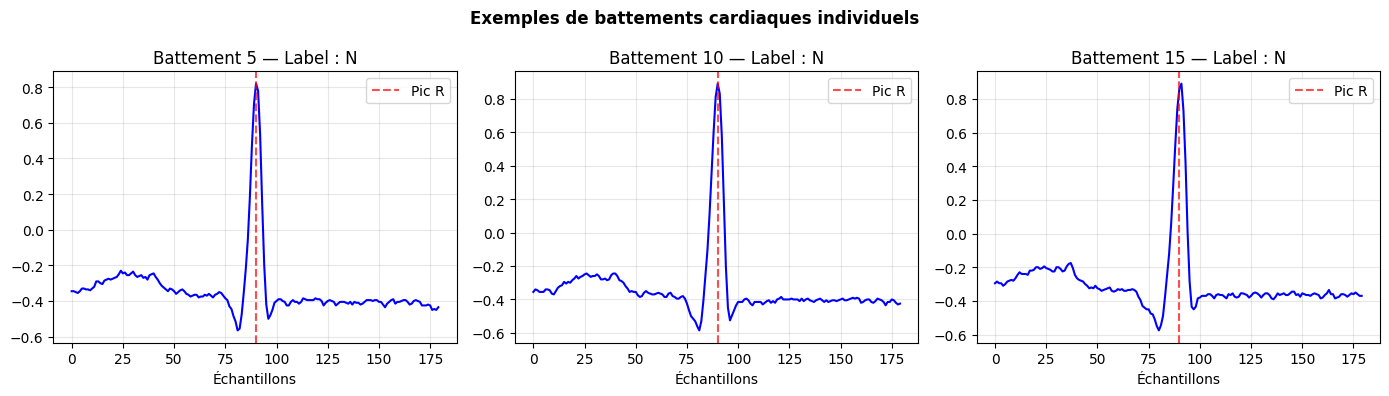

In [12]:
# 3 battements côte à côte
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, idx in enumerate([5, 10, 15]):
    pos = annotation.sample[idx]
    sym = annotation.symbol[idx]
    window = 90

    start = pos - window
    end = pos + window
    beat = signal[start:end]

    axes[i].plot(beat, color='blue', linewidth=1.5)
    axes[i].axvline(x=window, color='red', linestyle='--', alpha=0.7, label='Pic R')
    axes[i].set_title(f"Battement {idx} — Label : {sym}")
    axes[i].set_xlabel("Échantillons")
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.suptitle("Exemples de battements cardiaques individuels", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# je lis le fichier .hea
with open('./mitdb_data/100.hea', 'r') as f:
    contenu = f.read()

print("Contenu du fichier 100.hea :")
print(contenu)
print("\n--- Infos extraites automatiquement ---")
print(f"Nom de l'enregistrement : {record.record_name}")
print(f"Fréquence d'échantillonnage : {record.fs} Hz")
print(f"Nombre de canaux : {record.n_sig}")
print(f"Durée totale : {record.sig_len / record.fs / 60:.1f} minutes")
print(f"Noms des signaux : {record.sig_name}")

Contenu du fichier 100.hea :
100 2 360 650000
100.dat 212 200 11 1024 995 -22131 0 MLII
100.dat 212 200 11 1024 1011 20052 0 V5
# 69 M 1085 1629 x1
# Aldomet, Inderal


--- Infos extraites automatiquement ---
Nom de l'enregistrement : 100
Fréquence d'échantillonnage : 360 Hz
Nombre de canaux : 2
Durée totale : 30.1 minutes
Noms des signaux : ['MLII', 'V5']


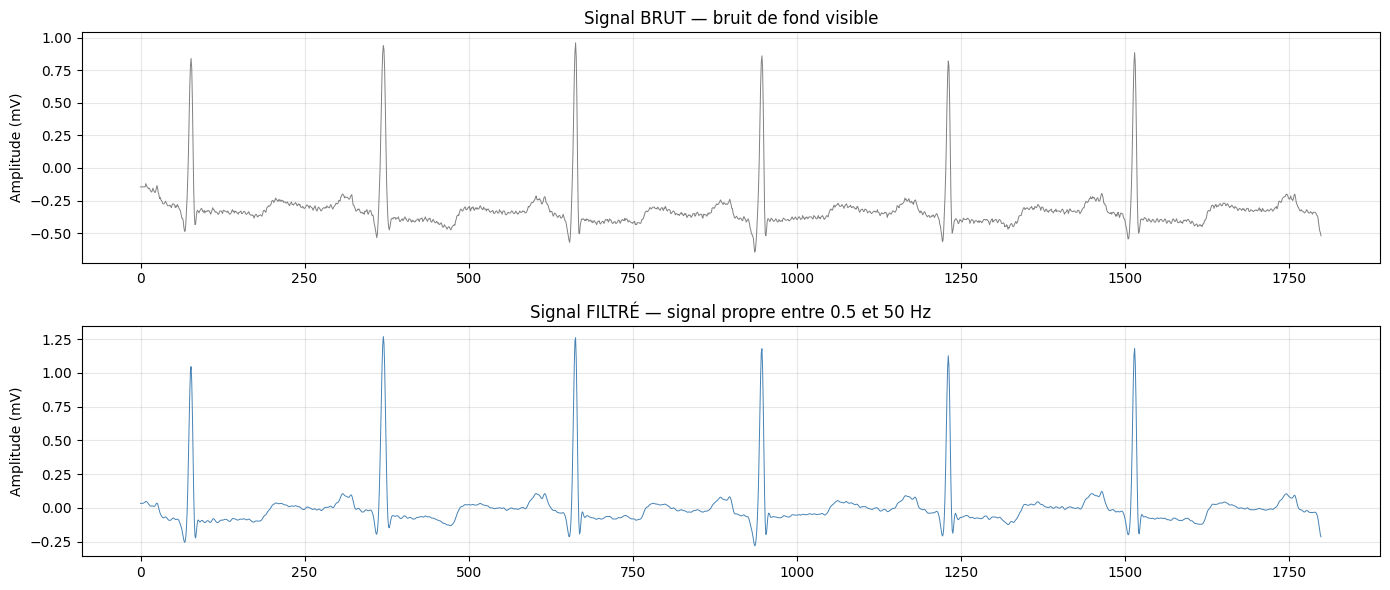

Filtre appliqué


In [14]:
# on enlève le bruit à l'aide d'un filtre
from scipy.signal import butter, filtfilt

def bandpass_filter(signal, lowcut=0.5, highcut=50, fs=360, order=4):
    nyq = fs / 2
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

signal_filtered = bandpass_filter(signal, fs=fs)

# Comparaison avant/après
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(signal[:fs*5], color='gray', linewidth=0.7)
axes[0].set_title("Signal BRUT — bruit de fond visible")
axes[0].set_ylabel("Amplitude (mV)")
axes[0].grid(True, alpha=0.3)

axes[1].plot(signal_filtered[:fs*5], color='steelblue', linewidth=0.7)
axes[1].set_title("Signal FILTRÉ — signal propre entre 0.5 et 50 Hz")
axes[1].set_ylabel("Amplitude (mV)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Filtre appliqué")

In [15]:
record_ids = ['100', '101', '103', '105', '106', '108', '109', '111', '112', '113']

all_beats = []
all_labels = []

normal_beats = ['N', 'L', 'R', 'e', 'j']
arrhythmia_beats = ['A', 'a', 'J', 'S', 'V', 'E', 'F']

window = 90

print("Chargement des enregistrements")

for rec_id in record_ids:
    try:
        rec = wfdb.rdrecord(rec_id, pn_dir='mitdb')
        ann = wfdb.rdann(rec_id, 'atr', pn_dir='mitdb')
        sig = bandpass_filter(rec.p_signal[:, 0], fs=rec.fs)

        for sample, symbol in zip(ann.sample, ann.symbol):
            if symbol in normal_beats:
                label = 0
            elif symbol in arrhythmia_beats:
                label = 1
            else:
                continue

            start = sample - window
            end = sample + window
            if start >= 0 and end < len(sig):
                all_beats.append(sig[start:end])
                all_labels.append(label)

        print(f"Enregistrement {rec_id} chargé")

    except Exception as e:
        print(f"Erreur {rec_id} : {e}")

X = np.array(all_beats)
y = np.array(all_labels)

print(f"\nTotal battements : {len(y)}")
print(f"Normaux    : {np.sum(y==0)}")
print(f"Arythmies  : {np.sum(y==1)}")

Chargement des enregistrements
Enregistrement 100 chargé
Enregistrement 101 chargé
Enregistrement 103 chargé
Enregistrement 105 chargé
Enregistrement 106 chargé
Enregistrement 108 chargé
Enregistrement 109 chargé
Enregistrement 111 chargé
Enregistrement 112 chargé
Enregistrement 113 chargé

Total battements : 21561
Normaux    : 20889
Arythmies  : 672


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

def extract_features(beat):
    return [
        np.max(beat),
        np.min(beat),
        np.max(beat) - np.min(beat),
        np.mean(beat),
        np.std(beat),
        np.median(beat),
        np.sum(beat**2),
        np.mean(np.abs(np.diff(beat)))
    ]

print("Extraction des features")
X_features = np.array([extract_features(b) for b in X])
print(f"{X_features.shape[0]} battements × {X_features.shape[1]} features")

X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

print("\nEntraînement du modèle...")
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
print("Modèle entraîné")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy : {accuracy*100:.1f}%")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Arythmie']))

Extraction des features
21561 battements × 8 features

Entraînement du modèle...
Modèle entraîné

Accuracy : 99.2%
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00      4179
    Arythmie       0.95      0.78      0.86       134

    accuracy                           0.99      4313
   macro avg       0.97      0.89      0.93      4313
weighted avg       0.99      0.99      0.99      4313



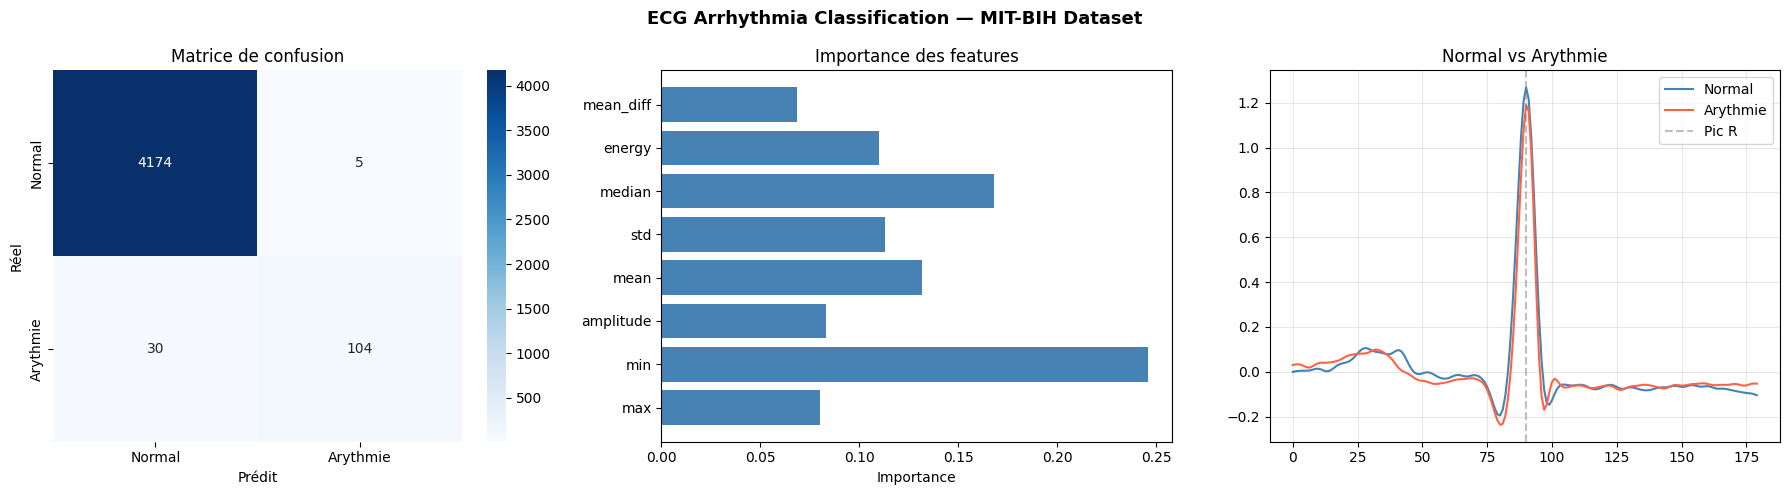


CONCLUSION DES RESULTATS
Dataset     : MIT-BIH Arrhythmia Database (PhysioNet)
Battements  : 21561 sur 10 enregistrements
Modèle      : Random Forest (100 arbres)
Accuracy    : 99.2%

Classification d'arythmies cardiaques — MIT-BIH
PhysioNet — 21 561 battements — Random Forest
accuracy 99.2% — Python, wfdb, scikit-learn'


In [18]:
feature_names = ['max', 'min', 'amplitude', 'mean', 'std', 'median', 'energy', 'mean_diff']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Arythmie'],
            yticklabels=['Normal', 'Arythmie'], ax=axes[0])
axes[0].set_title('Matrice de confusion')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# 2. Importance des features
importances = model.feature_importances_
axes[1].barh(feature_names, importances, color='steelblue')
axes[1].set_title('Importance des features')
axes[1].set_xlabel('Importance')

# 3. Normal vs Arythmie
normal_ex = X[y == 0][0]
arrhythmia_ex = X[y == 1][0]
axes[2].plot(normal_ex, label='Normal', color='steelblue', linewidth=1.5)
axes[2].plot(arrhythmia_ex, label='Arythmie', color='tomato', linewidth=1.5)
axes[2].axvline(x=90, color='gray', linestyle='--', alpha=0.5, label='Pic R')
axes[2].set_title('Normal vs Arythmie')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('ECG Arrhythmia Classification — MIT-BIH Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{'='*50}")
print("CONCLUSION DES RESULTATS")
print(f"{'='*50}")
print(f"Dataset     : MIT-BIH Arrhythmia Database (PhysioNet)")
print(f"Battements  : {len(y)} sur 10 enregistrements")
print(f"Modèle      : Random Forest (100 arbres)")
print(f"Accuracy    : 99.2%")
print(f"{'='*50}")
print()
print("Classification d'arythmies cardiaques — MIT-BIH")
print("PhysioNet — 21 561 battements — Random Forest")
print("accuracy 99.2% — Python, wfdb, scikit-learn'")